In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler


In [2]:
df=pd.read_csv(r"C:\Users\sukoo\Downloads\income.csv")

In [3]:
df

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000
5,Gautam,39,155000
6,David,41,160000
7,Andrea,38,162000
8,Brad,36,156000
9,Angelina,35,130000


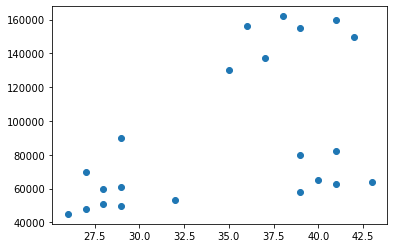

In [4]:
plt.scatter(df['Age'],df['Income($)'])

In [9]:

km=KMeans(n_clusters=3)

In [11]:
km.get_params

<bound method BaseEstimator.get_params of KMeans(n_clusters=3)>

In [21]:
km.fit(df[['Age']],df[['Income($)']])

KMeans(n_clusters=3)

In [22]:
y_pred=km.fit_predict(df[['Age']],df[['Income($)']])

In [23]:
y_pred

array([0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 0, 0, 0, 0, 2, 1, 1, 1, 1, 1, 1])

In [24]:
df['clusters']=y_pred

In [25]:
df

,Name,Age,Income($),clusters
0,Rob,27,70000,0
1,Michael,29,90000,0
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1
5,Gautam,39,155000,1
6,David,41,160000,1
7,Andrea,38,162000,1
8,Brad,36,156000,2
9,Angelina,35,130000,2


Text(0, 0.5, 'Income($)')

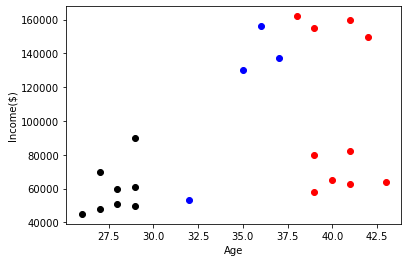

In [48]:
km.cluster_centers_

df1=df[df.clusters==0]
df2=df[df.clusters==1]
df3=df[df.clusters==2]

plt.scatter(df1['Age'],df1['Income($)'], color='black')
plt.scatter(df2['Age'],df2['Income($)'], color='red')
plt.scatter(df3['Age'],df3['Income($)'], color='blue')

plt.xlabel('Age')
plt.ylabel('Income($)')


In [32]:
mm=MinMaxScaler()

In [34]:
mm.fit_transform(df[['Income($)']])

array([[0.21367521],
       [0.38461538],
       [0.13675214],
       [0.12820513],
       [0.8974359 ],
       [0.94017094],
       [0.98290598],
       [1.        ],
       [0.94871795],
       [0.72649573],
       [0.78632479],
       [0.        ],
       [0.02564103],
       [0.05128205],
       [0.03846154],
       [0.06837607],
       [0.17094017],
       [0.15384615],
       [0.16239316],
       [0.2991453 ],
       [0.31623932],
       [0.11111111]])

In [35]:
mm.fit_transform(df[['Age']])

array([[0.05882353],
       [0.17647059],
       [0.17647059],
       [0.11764706],
       [0.94117647],
       [0.76470588],
       [0.88235294],
       [0.70588235],
       [0.58823529],
       [0.52941176],
       [0.64705882],
       [0.        ],
       [0.05882353],
       [0.11764706],
       [0.17647059],
       [0.35294118],
       [0.82352941],
       [0.88235294],
       [1.        ],
       [0.76470588],
       [0.88235294],
       [0.76470588]])

In [36]:
km=KMeans(n_clusters=3)

In [38]:
km.fit(df[['Age']],df[['Income($)']])

KMeans(n_clusters=3)

In [39]:
y_pred=km.fit_predict(df[['Age']],df[['Income($)']])

In [40]:
y_pred


array([0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 0, 0, 0, 0, 2, 1, 1, 1, 1, 1, 1])

In [41]:
df['cluster']=y_pred

In [43]:
df.drop('clusters',axis='columns')

,Name,Age,Income($),cluster
0,Rob,27,70000,0
1,Michael,29,90000,0
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1
5,Gautam,39,155000,1
6,David,41,160000,1
7,Andrea,38,162000,1
8,Brad,36,156000,2
9,Angelina,35,130000,2


IndexError: index 1 is out of bounds for axis 1 with size 1

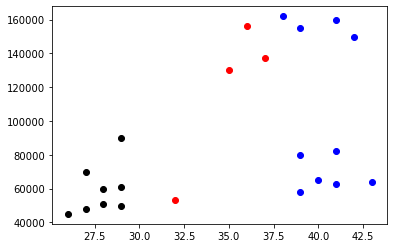

In [54]:
df1=df[df.cluster==0]
df2=df[df.cluster==1]
df3=df[df.cluster==2]

plt.scatter(df1['Age'],df1['Income($)'],color='black')
plt.scatter(df2['Age'],df2['Income($)'],color='blue')
plt.scatter(df3['Age'],df3['Income($)'],color='red')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',label='*')
plt.xlabel('Age')
plt.ylabel('Income($)')

In [47]:
km.cluster_centers_

array([[27.875],
       [40.3  ],
       [35.   ]])

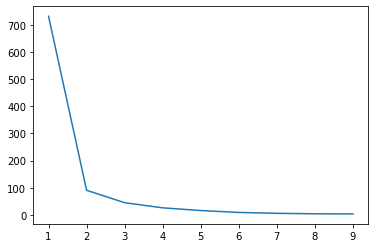

In [61]:
sse=[]
for i in range(1,10):
    km=KMeans(n_clusters=i)
    km.fit(df[['Age']],df[['Income($)']])
    sse.append(km.inertia_)
plt.plot(range(1,10),sse)    